In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "productivity"
namex = "Productivity"
d = 11

###threshold
graphsx = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/productivity_thresh_graphsummary.npy")
randomgraphsinfo


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Productivity (11),4.0,112,50,39,11,20.330357,15.991071,4.339286,45.54,9.069088,7.081356,1.987732,0,1,7,0,0
1,Productivity (11),4.5,112,50,39,11,25.598214,19.982143,5.616071,57.34,14.040155,10.830350,3.209805,0,0,6,0,1
2,Productivity (11),5.0,112,50,39,11,32.116071,25.080357,7.035714,71.94,21.887921,17.002419,4.885502,0,0,6,0,2
3,Productivity (11),5.5,112,50,39,11,38.803571,30.339286,8.464286,86.92,31.333333,24.426060,6.907273,0,0,6,0,3
4,Productivity (11),6.0,112,50,39,11,44.241071,34.562500,9.678571,99.10,39.637286,30.956494,8.680793,0,0,5,1,4
5,Productivity (11),6.5,112,50,39,11,46.696429,36.419643,10.276786,104.60,43.723010,34.105221,9.617789,0,0,5,13,5
6,Productivity (11),7.0,112,50,39,11,47.491071,37.035714,10.455357,106.38,45.163874,35.214631,9.949243,0,0,5,25,6
7,Productivity (11),7.5,112,50,39,11,47.732143,37.223214,10.508929,106.92,45.621334,35.569610,10.051724,0,0,5,35,7
8,Productivity (11),8.0,112,50,39,11,47.767857,37.258929,10.508929,107.00,45.689655,35.637931,10.051724,0,0,5,39,8
9,Productivity (11),8.5,112,50,39,11,47.839286,37.303571,10.535714,107.16,45.798068,35.701127,10.096940,0,0,4,5,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=True,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_thresh.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,r,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{2},{2: 1},96.845464,{2},{2: 1},96.845464,100.845464,"[4, 19, 47, 73]",...,"[4, 19, 47, 73]",4,4.0,112,50,0.080094,0.084996,0.080697,productivity (11),0
1,1,3,{2},{2: 1},96.845464,{2},{2: 1},96.845464,99.845464,"[4, 19, 47]",...,"[4, 19, 47]",3,4.0,112,50,0.079236,0.082400,0.082076,productivity (11),0
2,1,2,{2},{2: 1},96.845464,{2},{2: 1},96.845464,98.845464,"[4, 19]",...,"[4, 19]",2,4.0,112,50,0.089847,0.090801,0.178732,productivity (11),0
3,1,1,{2},{2: 1},96.845464,{2},{2: 1},96.845464,97.845464,[4],...,[4],1,4.0,112,50,0.111668,0.110874,0.137502,productivity (11),0
4,1,0,{2},{2: 1},96.845464,{2},{2: 1},96.845464,96.845464,[],...,[],0,4.0,112,50,0.084859,0.114420,0.144180,productivity (11),0
5,2,4,"{2, 31}","{2: 1, 31: 1}",103.500000,"{2, 31}","{2: 1, 31: 1}",103.500000,107.500000,"[4, 19, 47, 73]",...,"[4, 19, 47, 73]",4,4.0,112,50,0.235640,0.197699,0.162720,productivity (11),0
6,2,3,"{2, 31}","{2: 1, 31: 1}",103.500000,"{2, 31}","{2: 1, 31: 1}",103.500000,106.500000,"[4, 19, 47]",...,"[4, 19, 47]",3,4.0,112,50,0.160044,0.165373,0.166536,productivity (11),0
7,2,2,"{2, 31}","{2: 1, 31: 1}",103.500000,"{2, 31}","{2: 1, 31: 1}",103.500000,105.500000,"[4, 19]",...,"[4, 19]",2,4.0,112,50,0.195333,0.179516,0.162710,productivity (11),0
8,2,1,"{2, 31}","{2: 1, 31: 1}",103.500000,"{2, 31}","{2: 1, 31: 1}",103.500000,104.500000,[4],...,[4],1,4.0,112,50,0.171479,0.160376,0.163399,productivity (11),0
9,2,0,"{2, 31}","{2: 1, 31: 1}",103.500000,"{2, 31}","{2: 1, 31: 1}",103.500000,103.500000,[],...,[],0,4.0,112,50,0.165005,0.164982,0.188570,productivity (11),0


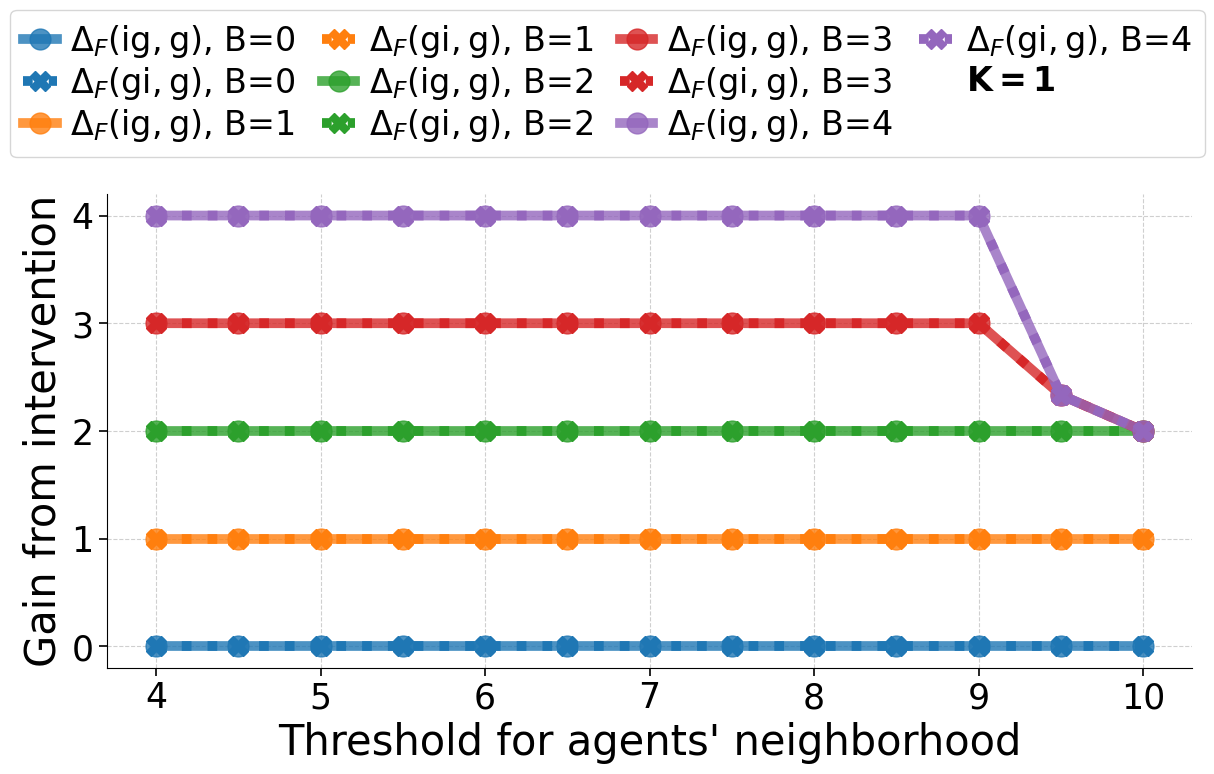

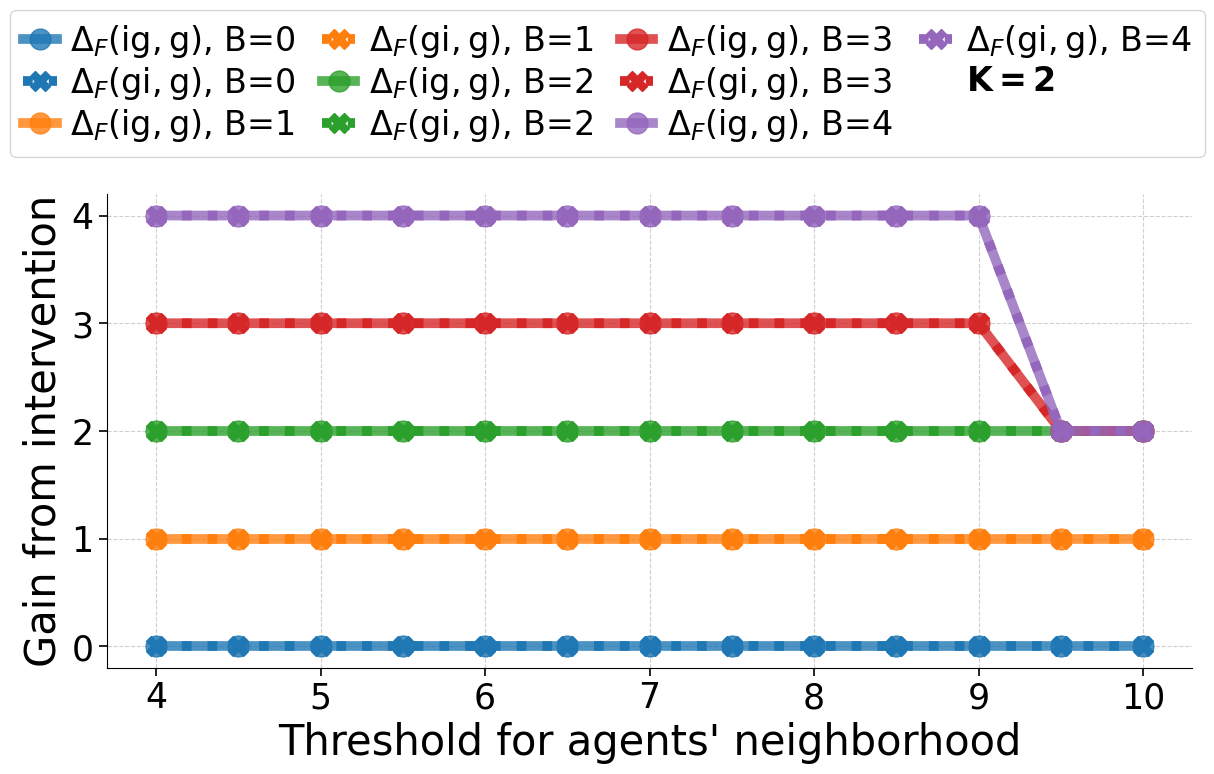

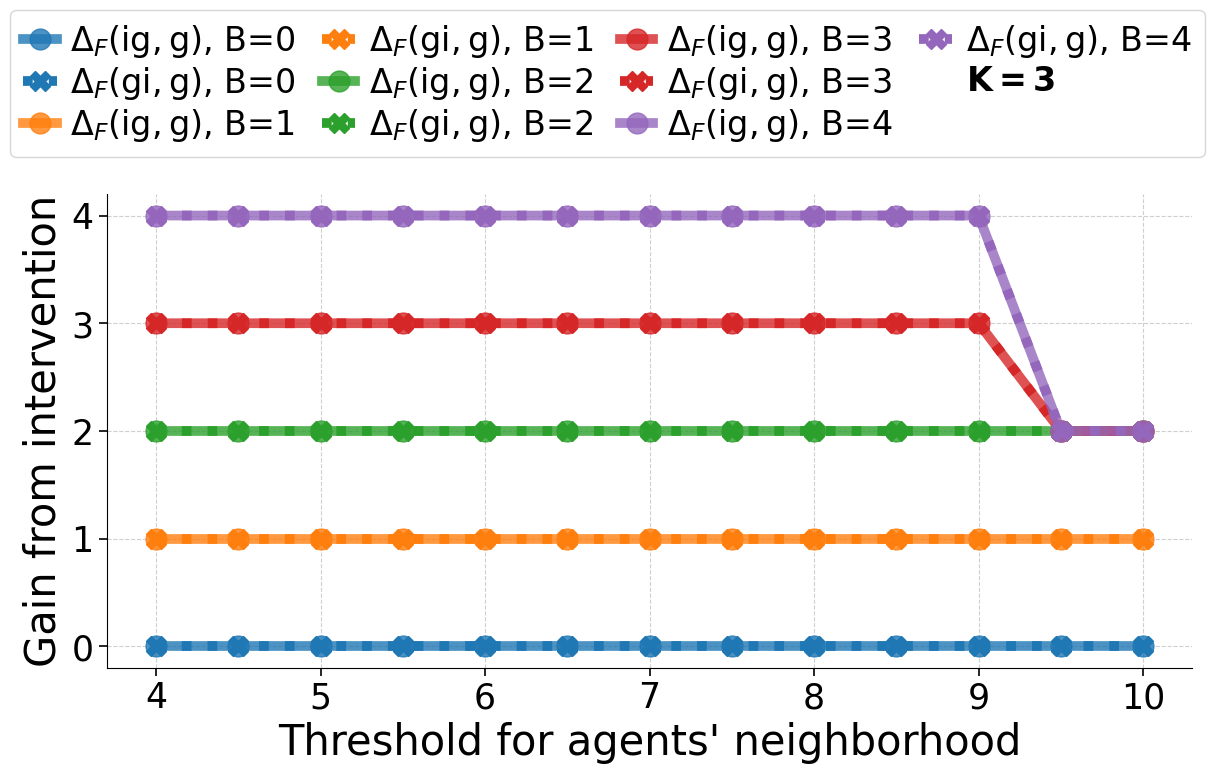

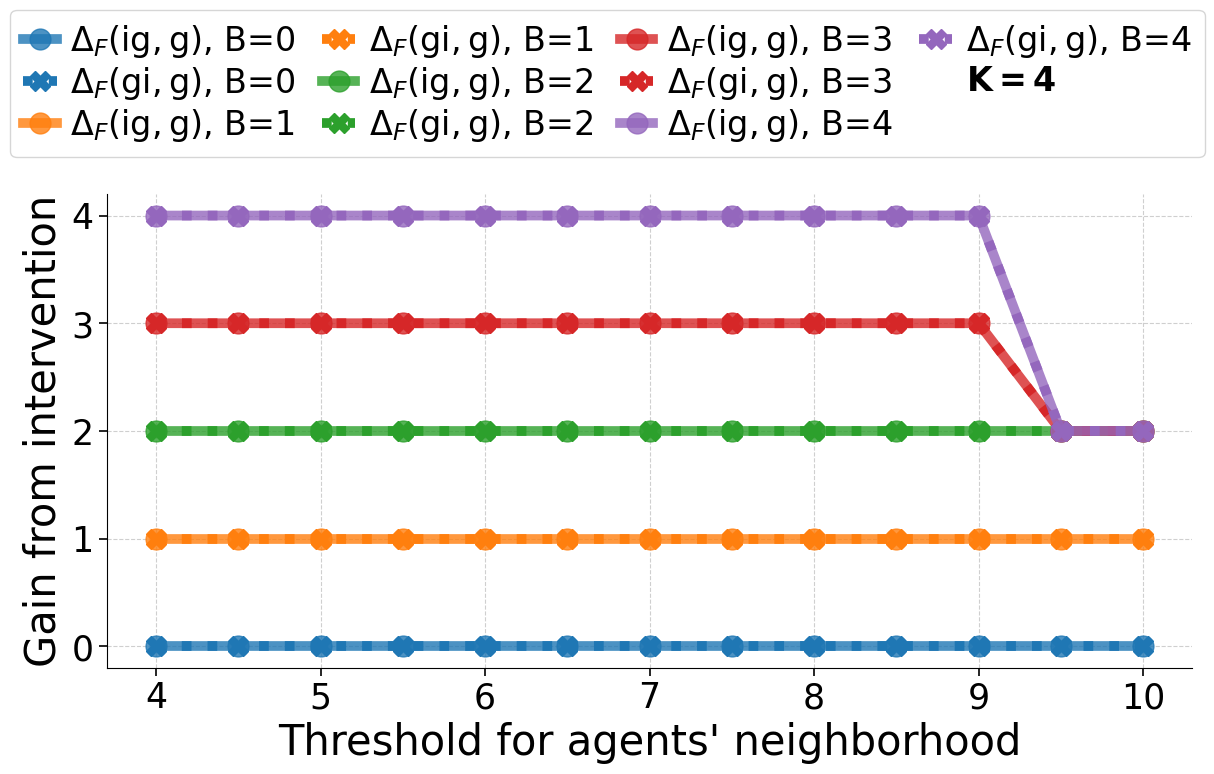

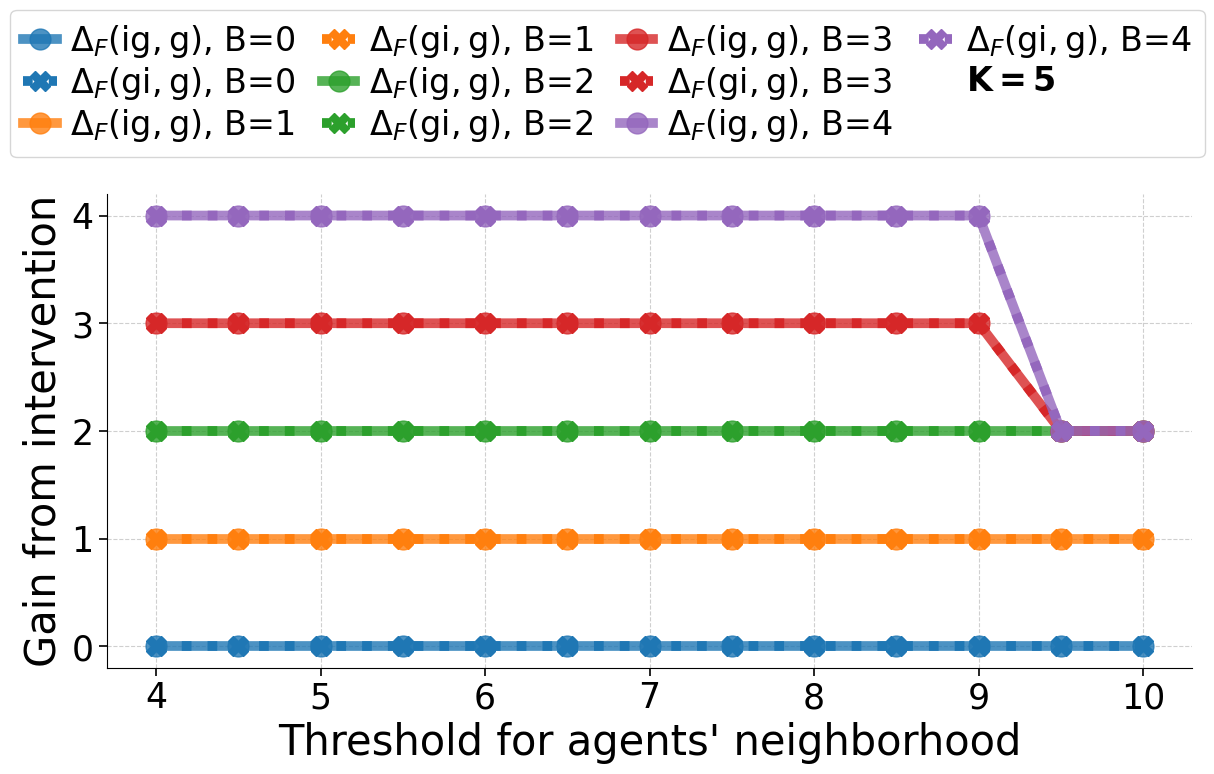

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                                      thresh = True, 
                                      save_as = "./im_results/figures/"+name+"_imb4aftersm_results_thresh")